from google.colab import drive
drive.mount('/content/drive')am

!cp  -r /content/drive/MyDrive/Colab_Notebooks/data/images/image_train /content
print("Ok!")
print("nombre d'images :")
!find /content/image_train/ -name '*.jpg' | wc -l

!python --version
!find /content/image_train/ -name '*.jpg' | wc -l

In [1]:
import sys
sys.path.append('../src')
#sys.path.append('/content/drive/MyDrive/Colab_Notebooks/src')
#!pip install -r /content/drive/MyDrive/Colab_Notebooks/requirements.txt

In [14]:
import configparser
config = configparser.ConfigParser()
config.read('../Rakuten_config2.ini')
#config.read('/content/drive/MyDrive/Colab_Notebooks/Rakuten_config_colab.ini')
def get_RACINE_DOSSIER() :
    return config['DOSSIER']['RACINE_DOSSIER']
def get_RACINE_IMAGES() :
    return config['DOSSIER']['RACINE_IMAGES']
def get_RACINE_FICHIERS() :
    return config['DOSSIER']['RACINE_SAUVEGARDE']      
print( get_RACINE_DOSSIER())   
print( get_RACINE_IMAGES())   

../input/
../data/images/image_train/


In [3]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import os
import cv2

In [4]:
# lecture des données sources d'entrainement
df_feats=pd.read_csv(get_RACINE_DOSSIER() + 'X_train_update.csv')

# lecture des données cibles d'entrainement
df_target=pd.read_csv(get_RACINE_DOSSIER() + 'Y_train_CVw08PX.csv')


# création d'un dataframe globale -  jointure
df=df_feats.merge(df_target,on='Unnamed: 0',how='inner')
df.rename(columns={'Unnamed: 0': 'Id'}, inplace=True)
cat=df_target['prdtypecode'].sort_values().unique()
cat
nomenclature=pd.read_csv(get_RACINE_DOSSIER() + 'NOMENCLATURE.csv',header=0,encoding='utf-8',sep=';',index_col=0)
catdict=nomenclature.to_dict()['definition']

In [5]:
df_feats.head(5)

,Unnamed: 0,designation,description,productid,imageid
0,0,Olivia: Personalisiertes Notizbuch / 150 Seite...,NaN,3804725264,1263597046
1,1,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,NaN,436067568,1008141237
2,2,Grand Stylet Ergonomique Bleu Gamepad Nintendo...,PILOT STYLE Touch Pen de marque Speedlink est ...,201115110,938777978
3,3,Peluche Donald - Europe - Disneyland 2000 (Mar...,NaN,50418756,457047496
4,4,La Guerre Des Tuques,Luc a des id&eacute;es de grandeur. Il veut or...,278535884,1077757786


In [6]:
df_target.head(5)

,Unnamed: 0,prdtypecode
0,0,10
1,1,2280
2,2,50
3,3,1280
4,4,2705


In [7]:
df['nom_image']=df.apply(lambda row: "image_" +  str(row['imageid']) 
                                     + "_product_" + str(row['productid']) + ".jpg",axis=1)
print("Nb enreg ", str(df.shape[0]))
df.head(5)
df_img=df.copy()

Nb enreg  84916


import cv2
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

# Fonction pour calculer la netteté d'une image
def calculate_sharpness(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        return None
    laplacian_var = cv2.Laplacian(image, cv2.CV_64F).var()
    return laplacian_var

# Dossier contenant les images (organisé en sous-dossiers par catégorie)
base_dir = 'chemin/vers/votre/dossier/images'

# Dictionnaire pour stocker les résultats
results = {'category': [], 'image_path': [], 'sharpness': []}

# Parcourir les sous-dossiers et calculer la netteté
for category in os.listdir(base_dir):
    category_dir = os.path.join(base_dir, category)
    if os.path.isdir(category_dir):
        for image_name in os.listdir(category_dir):
            image_path = os.path.join(category_dir, image_name)
            sharpness = calculate_sharpness(image_path)
            if sharpness is not None:
                results['category'].append(category)
                results['image_path'].append(image_path)
                results['sharpness'].append(sharpness)

# Convertir les résultats en DataFrame
df = pd.DataFrame(results)

# Calculer les statistiques par catégorie
stats_by_category = df.groupby('category')['sharpness'].describe()

# Afficher les statistiques
print(stats_by_category)

# Visualiser les résultats
plt.figure(figsize=(12, 6))
df.boxplot(column='sharpness', by='category', grid=False, rot=90)
plt.title('Comparison of Image Sharpness by Category')
plt.suptitle('')
plt.xlabel('Category')
plt.ylabel('Sharpness')
plt.show()


### test de lecture d'images

../data/images/image_train/image_1319132924_product_4217994799.jpg
Sharpness: 18.15228


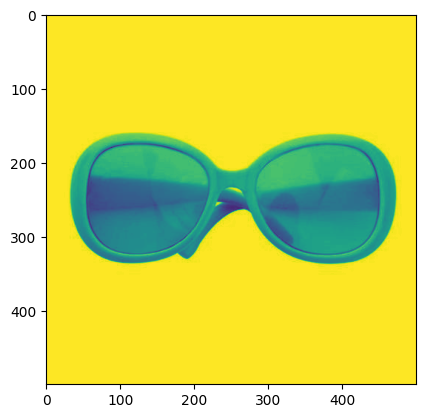

../data/images/image_train/image_1318786307_product_4217852988.jpg
Sharpness: 14.049055956735996


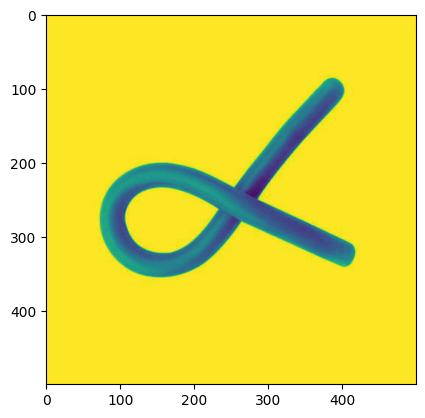

../data/images/image_train/image_1271444953_product_3976920344.jpg
Sharpness: 12.027131452400004


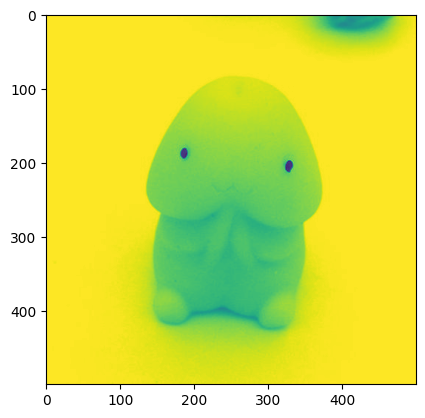

../data/images/image_train/image_1320225003_product_4215694880.jpg
Sharpness: 1.312776


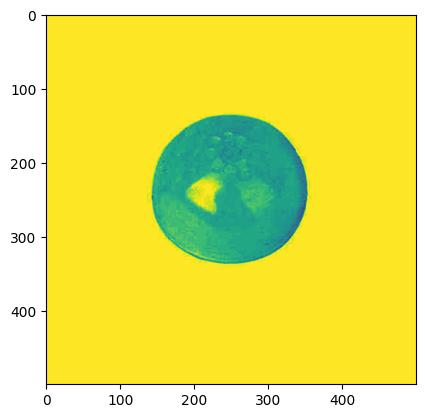

../data/images/image_train/image_1146793918_product_2515635680.jpg
Sharpness: 17.703667940464005


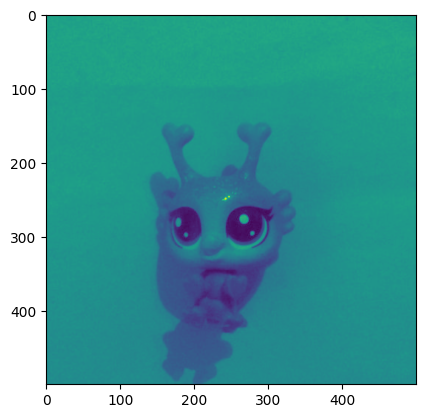

../data/images/image_train/image_1261195300_product_3898711669.jpg
Sharpness: 11.68068


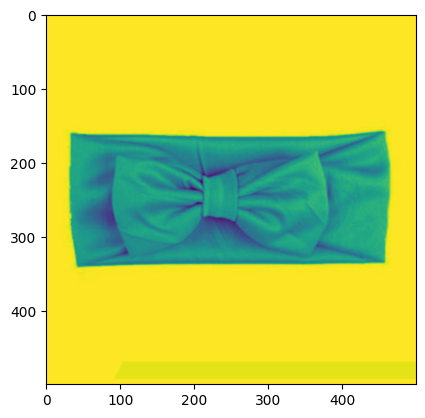

../data/images/image_train/image_1266794381_product_3940029089.jpg
Sharpness: 16.4262367216


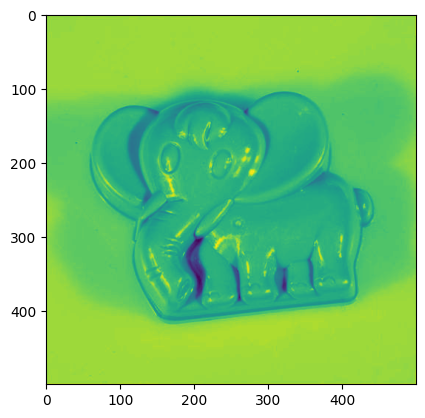

../data/images/image_train/image_1307268773_product_4171074435.jpg
Sharpness: 14.560744


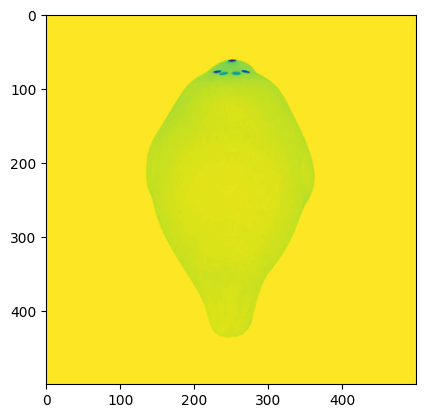

../data/images/image_train/image_1261183875_product_3898711376.jpg
Sharpness: 8.071439686400002


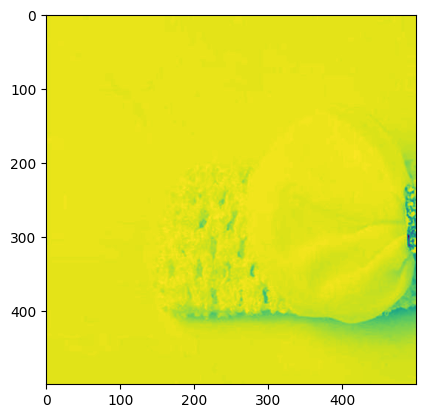

../data/images/image_train/image_1254365032_product_3861177574.jpg
Sharpness: 16.362448


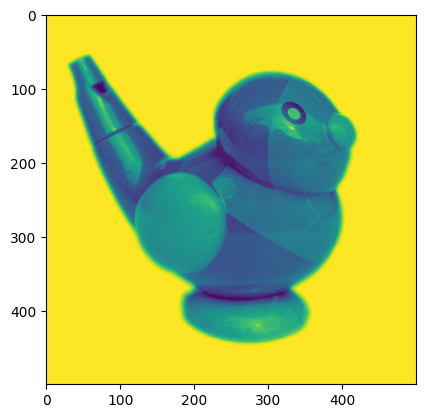

../data/images/image_train/image_1250156263_product_3830391201.jpg
Sharpness: 15.122391998976


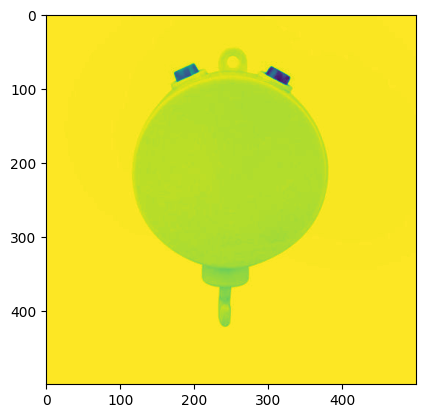

../data/images/image_train/image_1317401754_product_4212780747.jpg
Sharpness: 16.026464


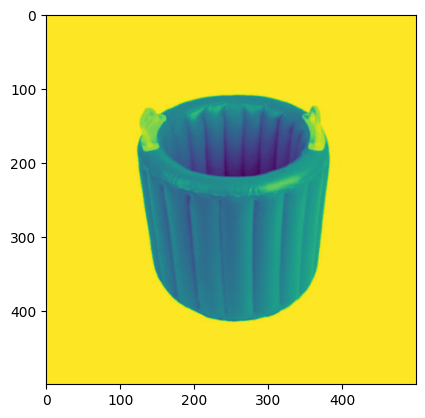

../data/images/image_train/image_1236526152_product_3708926457.jpg
Sharpness: 15.146672


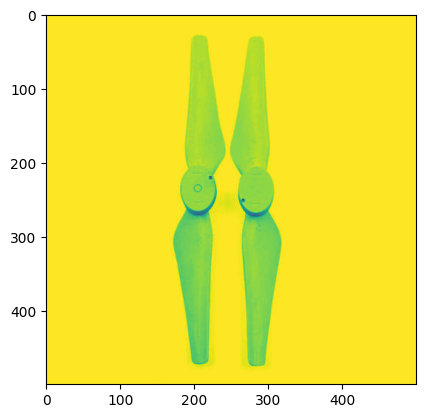

../data/images/image_train/image_1307425911_product_4171079683.jpg
Sharpness: 10.75892


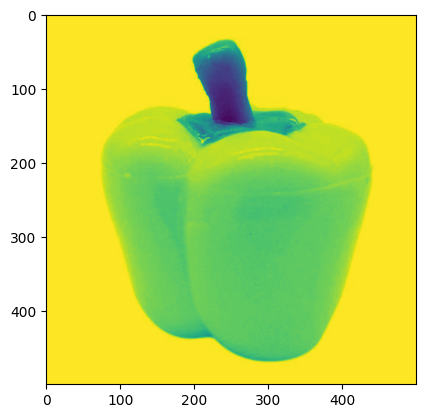

../data/images/image_train/image_1328348644_product_4250681803.jpg
Sharpness: 17.236996750575997


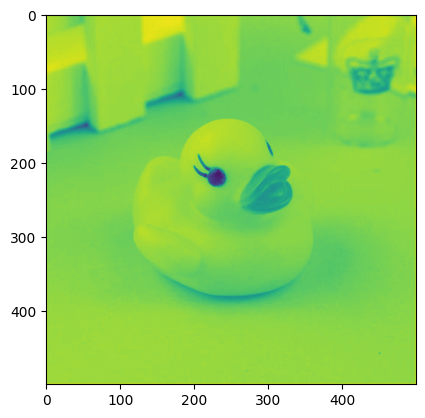

../data/images/image_train/image_1250157428_product_3830391286.jpg
Sharpness: 9.970872


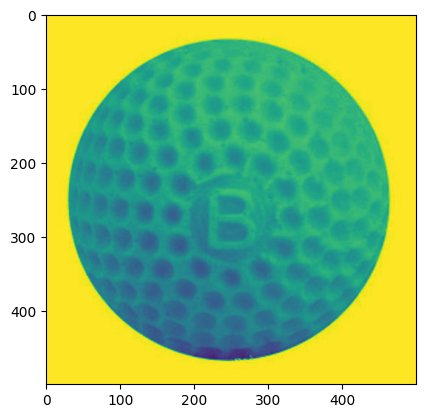

../data/images/image_train/image_1169778890_product_2878038864.jpg
Sharpness: 4.352464


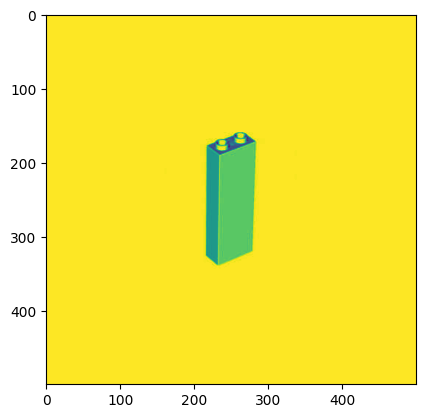

../data/images/image_train/image_994764439_product_302646570.jpg
Sharpness: 18.5044


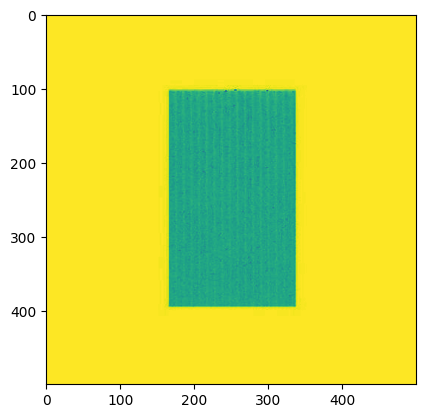

../data/images/image_train/image_1215379892_product_3470111496.jpg
Sharpness: 11.079753323504004


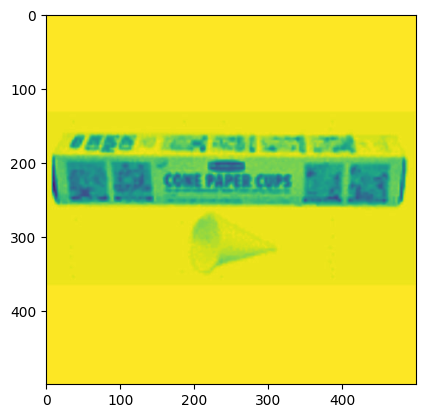

../data/images/image_train/image_1302249863_product_3793782107.jpg
Sharpness: 0.0


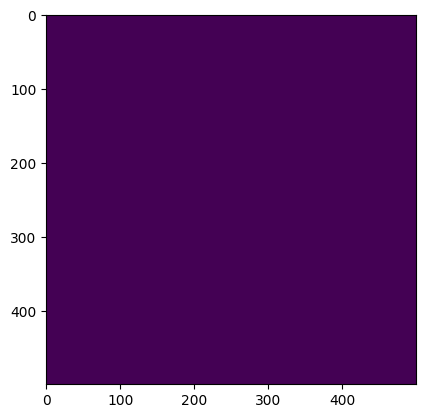

../data/images/image_train/image_987568238_product_294339887.jpg
Sharpness: 16.929459741936


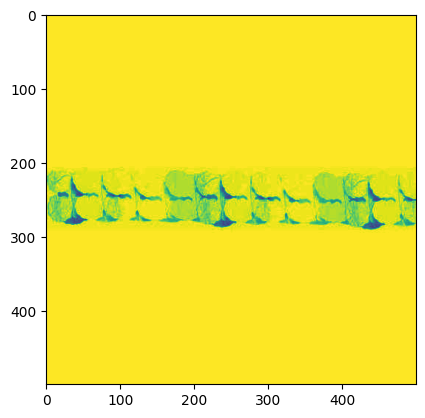

../data/images/image_train/image_1320461487_product_4221384887.jpg
Sharpness: 15.651056


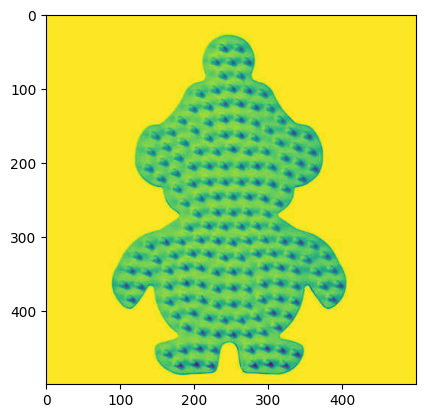

../data/images/image_train/image_1323959998_product_4232365042.jpg
Sharpness: 16.222032


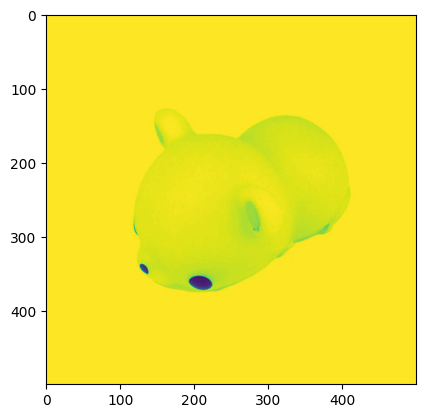

../data/images/image_train/image_1318959640_product_4213868749.jpg
Sharpness: 2.371656


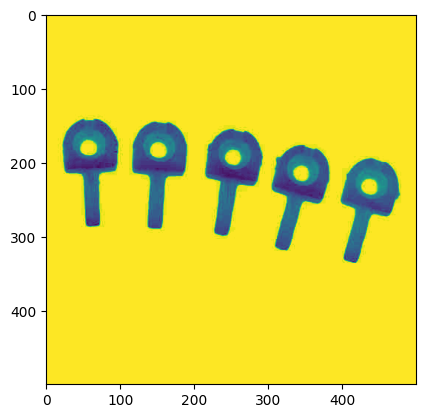

../data/images/image_train/image_1261269190_product_3898719959.jpg
Sharpness: 11.141576


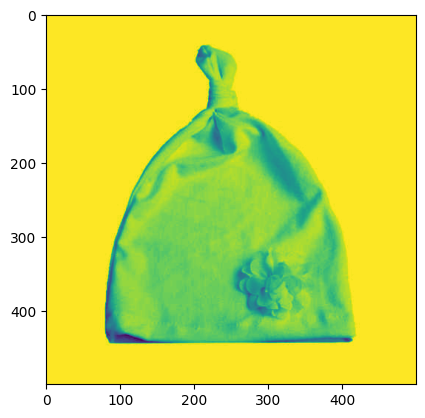

../data/images/image_train/image_1280417250_product_4044747438.jpg
Sharpness: 16.900056


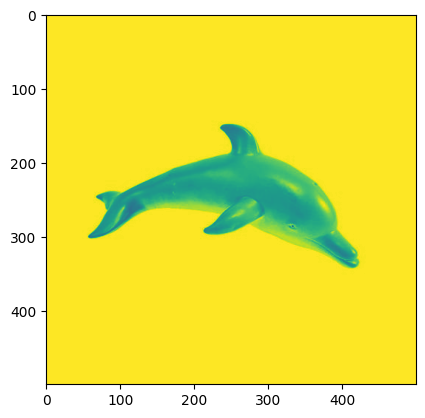

../data/images/image_train/image_1144107326_product_1123532939.jpg
Sharpness: 12.641144


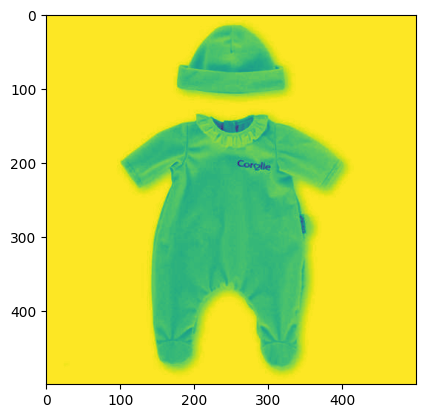

../data/images/image_train/image_1245205362_product_3789597364.jpg
Sharpness: 16.686083999216002


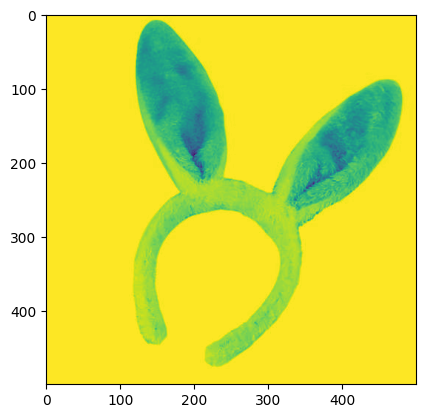

../data/images/image_train/image_1318750423_product_4215569304.jpg
Sharpness: 8.804232


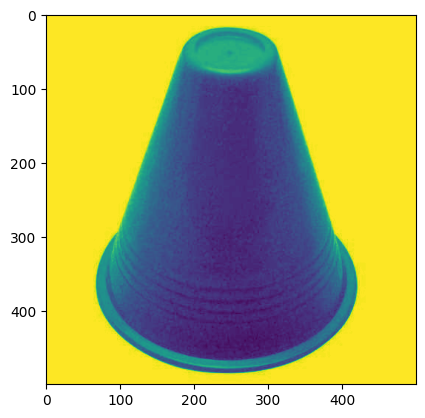

../data/images/image_train/image_1289249447_product_4087633655.jpg
Sharpness: 16.972112


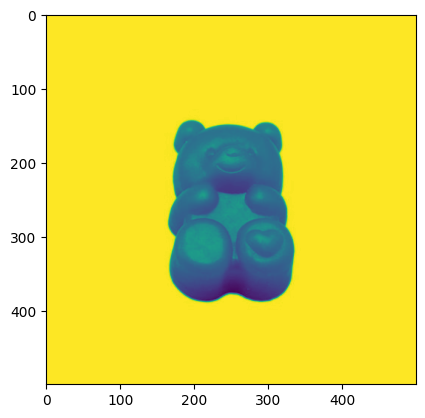

../data/images/image_train/image_1289121202_product_4085973516.jpg
Sharpness: 16.900056


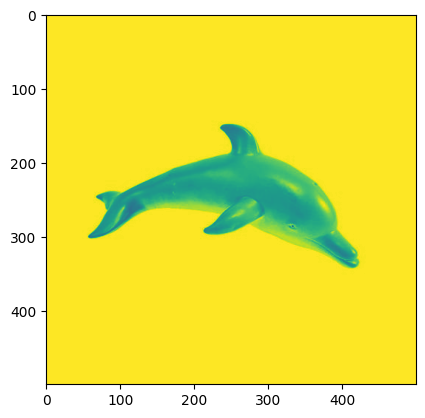

../data/images/image_train/image_1318960759_product_4213869198.jpg
Sharpness: 18.3536


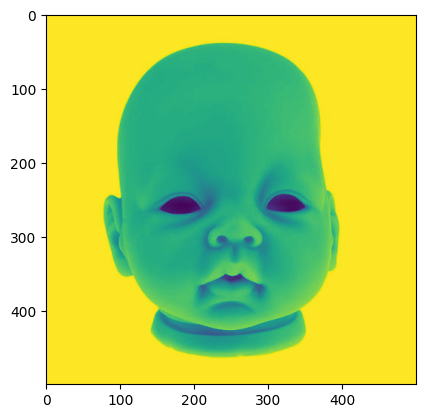

../data/images/image_train/image_1250160290_product_3830391465.jpg
Sharpness: 18.40744


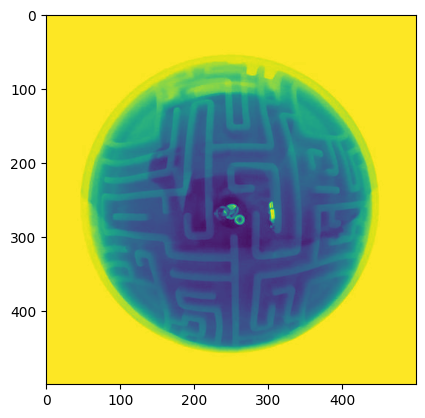

../data/images/image_train/image_1164148559_product_2779144310.jpg
Sharpness: 8.087735993600003


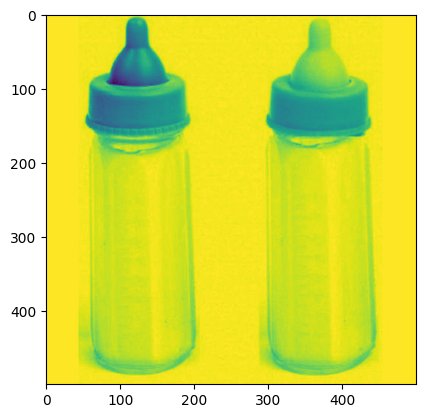

../data/images/image_train/image_1240756845_product_3748222794.jpg
Sharpness: 16.509384


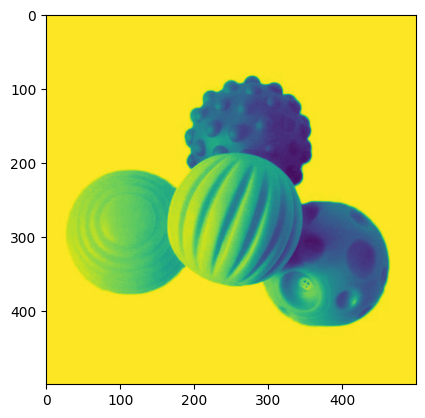

../data/images/image_train/image_1312603935_product_4195550042.jpg
Sharpness: 3.267352


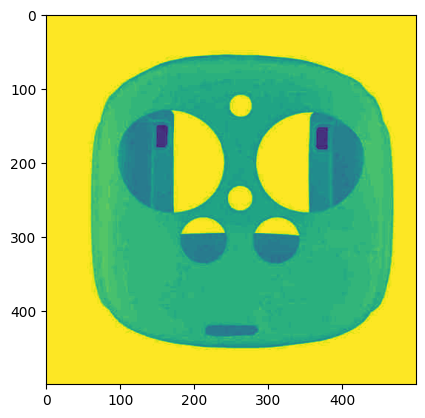

4870
(4870, 500, 500)


In [8]:
import os
import cv2
import numpy as np

from PIL import Image

def measure_sharpness(image):
    laplacian = cv2.Laplacian(image, cv2.CV_64F)
    return np.var(laplacian)

# Définir le chemin du dossier contenant les images
#folder_path = "C:\\Users\\MANUADMIN\\python\\DataScience\\Datascientest\\PROJET\\images\\image_train"
#folder_path = "C:\\Users\\shaky\\anaconda3\\envs\\Datascientest\\Datascience\\PROJET\\images\\image_train"
folder_path = get_RACINE_IMAGES() 


df_img=df[df['prdtypecode'].isin([40,50,60,1280])]
#print(df_img.head())

# Charger les images et les stocker dans un tableau
image_list = []


for filename in df_img['nom_image'][df_img['prdtypecode']==1280]:
    #print(os.path.join(folder_path, filename))
    #image = Image.open(os.path.join(folder_path, filename))
    #image.show()
    img = cv2.imread(os.path.join(folder_path, filename))
    if img is not None:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        sharpness = measure_sharpness(gray)
        #print('Sharpness:', sharpness)
        if sharpness < 20:
            print(os.path.join(folder_path, filename))
            print('Sharpness:', sharpness)
            plt.imshow(gray)
            plt.show()
        image_list.append(gray)



# Convertir la liste d'images en un tableau numpy
images = np.array(image_list)
print(len(images))
print(images.shape)


# Afficher la première image
image=image_list[0]
#plt.imshow(image)
#plt.show()

#sharpness = measure_sharpness(image)
#print('Sharpness:', sharpness)




In [9]:
def measure_sharpness(image):
    laplacian = cv2.Laplacian(image, cv2.CV_64F)
    return np.var(laplacian)

sharpness = measure_sharpness(image)
print('Sharpness:', sharpness)


Sharpness: 431.738072


(4870, 500, 500)


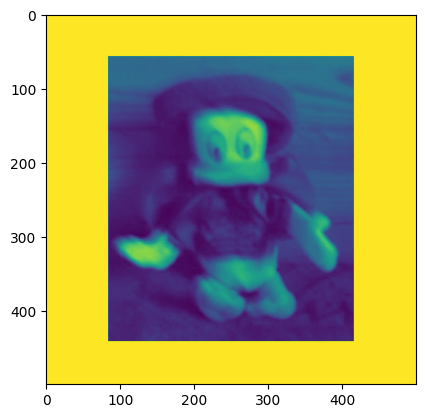

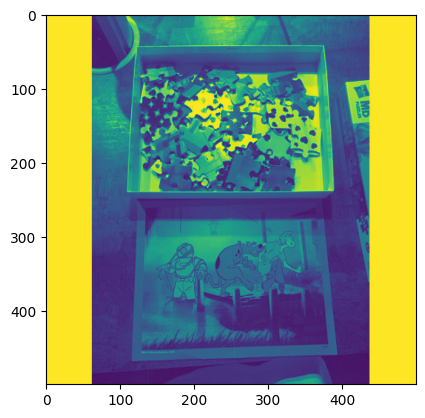

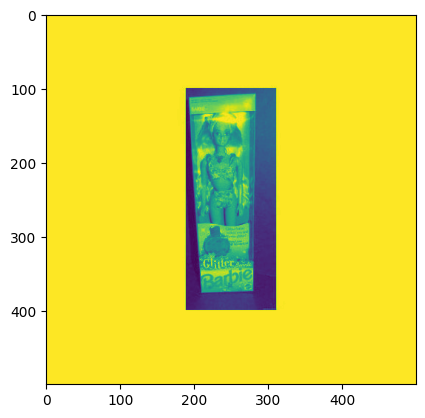

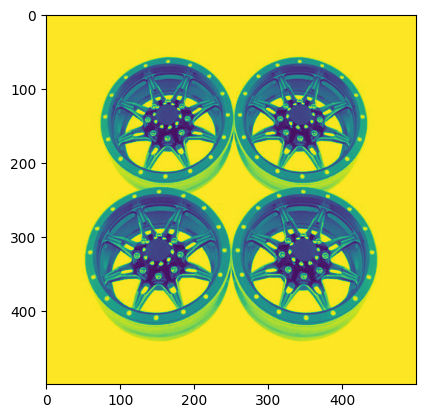

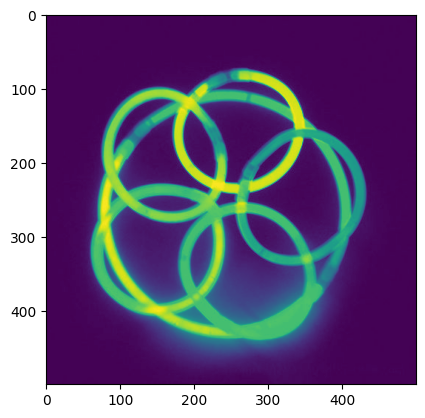

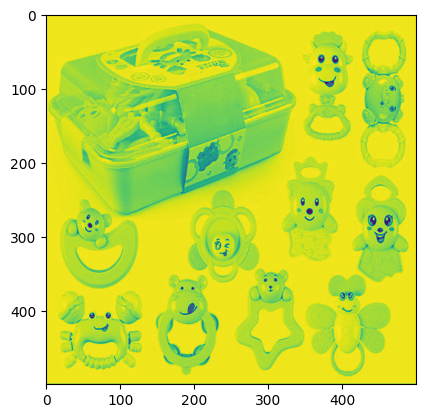

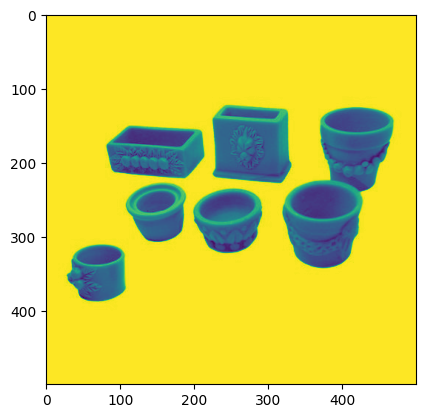

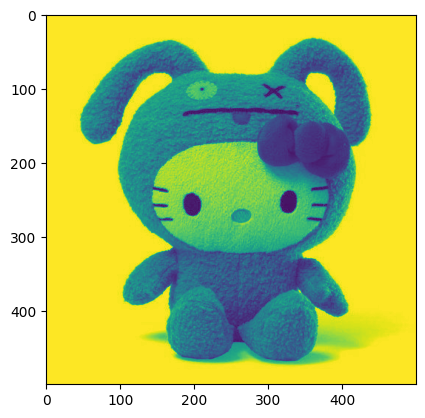

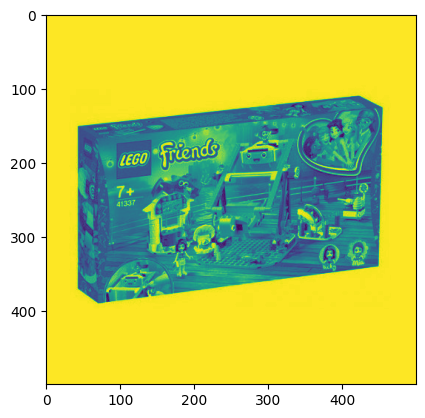

In [10]:
print(images.shape)
for i in range(9):
    image=images[i,:,:]
    plt.imshow(image)
    plt.show()

### test de contours et de formes (NB angles et de cercles)

In [11]:
Dfcontour=pd.DataFrame()
# Définir les classes de formes
classes = {0: 'cercle', 2: 'ligneE', 3: 'triangle', 4: 'rectangle', 5: 'pentagone', 6: 'hexagone'}
for i in range(len(images)):
    gray=images[i,:,:]
    # Convertir l'image en niveaux de gris
    #gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    # Appliquer un filtre pour réduire le bruit de l'image
    gray_blur = cv2.GaussianBlur(gray, (3, 3), 0)
    # Détecter les contours de l'image
    edges = cv2.Canny(gray_blur, 50, 150, apertureSize=3)
    # Extraire les caractéristiques des contours détectés
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    shapes = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        perimeter = cv2.arcLength(cnt, True)
        if perimeter == 0 :
            circularity = 0
        else :    
            circularity = 4 * np.pi * area / perimeter ** 2
        approx = cv2.approxPolyDP(cnt, 0.01 * perimeter, True)
        corners = len(approx)
        shapes.append((corners, circularity))
        """
        for contour in contours:
            # Approximer le contour
            epsilon = 0.02 * cv2.arcLength(contour, True)
            approx = cv2.approxPolyDP(contour, epsilon, True)

            # Classer la forme en fonction du nombre de sommets
            num_vertices = len(approx)
            shape = classes.get(num_vertices, "unknown")
            print("Shape: ", shape)
        """  
    if len(shapes) != 0 :      
        if len(Dfcontour) == 0 :
            Dfcontour =pd.DataFrame(shapes, columns=['corners','circularity'])    
        else:
            Dfcontour = pd.concat([Dfcontour,pd.DataFrame(shapes, columns=['corners','circularity']) ]
                                  ,ignore_index=True,axis=0)
print(Dfcontour.head())    
    

   corners  circularity
0        4     0.710107
1        8     0.007081
2        8     0.003265
3        7     0.013843
4       12     0.009002


In [12]:
print(Dfcontour.info())   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 665191 entries, 0 to 665190
Data columns (total 2 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   corners      665191 non-null  int64  
 1   circularity  665191 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 10.2 MB
None


## Dataframe des contours par catégorie

In [13]:
df_img=df.copy()
Dfcontour=pd.DataFrame()
for c in cat:
    print("Catégorie : " , c,catdict[c])
    image_list=[]
    for filename in df_img[df_img['prdtypecode']==c]['nom_image']:
        img = cv2.imread(os.path.join(folder_path, filename))
        if img is not None:
            image_list.append(img)
    images = np.array(image_list)
    for i in range(len(images)):
        image=images[i,:,:,:]
        # Convertir l'image en niveaux de gris
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        # Appliquer un filtre pour réduire le bruit de l'image
        gray_blur = cv2.GaussianBlur(gray, (3, 3), 0)
        # Détecter les contours de l'image
        edges = cv2.Canny(gray_blur, 50, 150, apertureSize=3)
        # Extraire les caractéristiques des contours détectés
        contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        shapes = []
        for cnt in contours:
            area = cv2.contourArea(cnt)
            perimeter = cv2.arcLength(cnt, True)
            if perimeter == 0 :
                circularity = 0
            else :    
                circularity = 4 * np.pi * area / perimeter ** 2
            approx = cv2.approxPolyDP(cnt, 0.01 * perimeter, True)
            corners = len(approx)
            #print("---------------")
            #print(area,perimeter,circularity,corners)
            shapes.append((c,corners, circularity))
        if len(shapes) != 0 :          
            if len(Dfcontour) == 0 :
                Dfcontour =pd.DataFrame(shapes, columns=['prdtypecode','corners','circularity'])    
            else:
                Dfcontour = pd.concat([Dfcontour,pd.DataFrame(shapes, columns=['prdtypecode','corners','circularity']) ]
                                      ,ignore_index=True,axis=0)
print(Dfcontour.head())    

Catégorie :  10 livres
Catégorie :  40 jeux video pour pc et consoles
Catégorie :  50  accesoires jeux video
Catégorie :  60 consoles de jeux video
Catégorie :  1140 produits derives “geeks” et figurines
Catégorie :  1160 cartes collectionables
Catégorie :  1180 figurines collectionables pour jeux de societe
Catégorie :  1280 jouets, peluches, poupees
Catégorie :  1281 jeux de societe/cartes
Catégorie :  1300 Petites voitures (jouets) et maquettes
Catégorie :  1301 accesoires pour petis enfants/bebes et mobilier de jeu (flechettes, billard, babyfoot)
Catégorie :  1302 jeux d'exterieur
Catégorie :  1320 sacs pour femmes et accesore petite enfance
Catégorie :  1560 Mobilier et produits decoration/rangement pour la maison
Catégorie :  1920 linge de maison (cousins, rideaux, serviettes, nappes, draps)
Catégorie :  1940 nouriture (cafes,infusions,conserves, epices,etc)
Catégorie :  2060 lampes et accesoires decoration pour maison
Catégorie :  2220 accesoires mascots/pets
Catégorie :  2280 m

In [15]:
Dfcontour.to_csv(get_RACINE_FICHIERS()+'Dfcontour.csv')

In [16]:
Dfcontour= pd.read_csv(get_RACINE_FICHIERS()+'Dfcontour.csv')

### Histogramme des angles toutes catagories confonfues

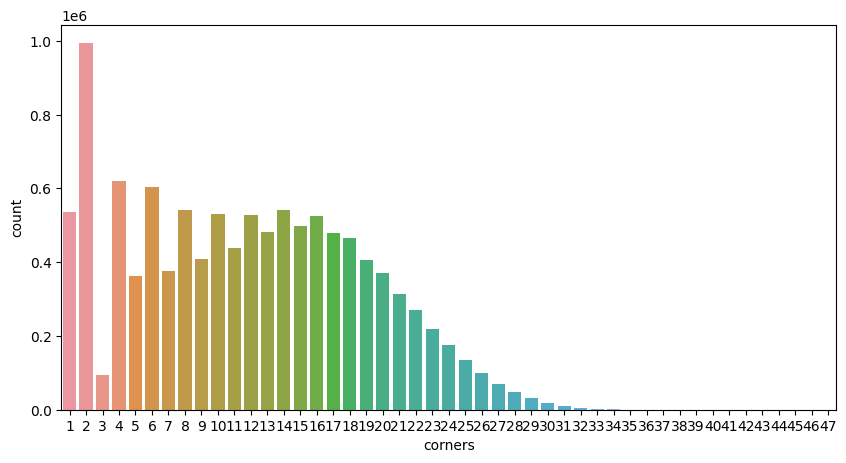

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
sns.countplot(x=Dfcontour['corners'])
plt.show()

In [ ]:
### Histogramme des circularités toutes catagories confonfues

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


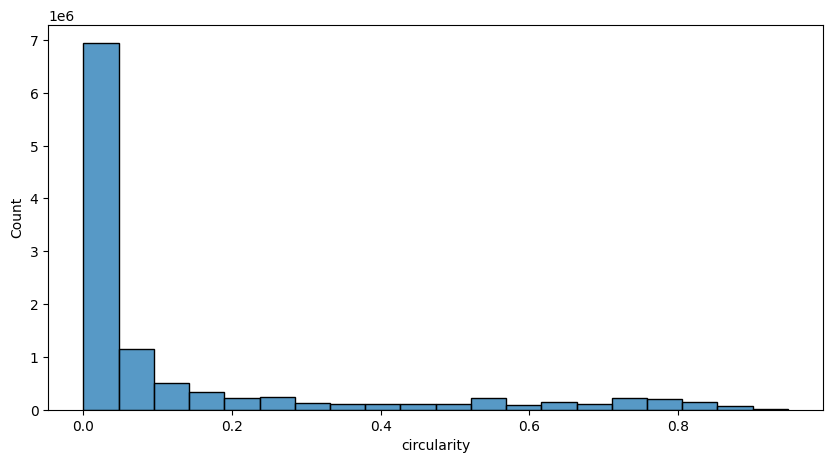

In [18]:
plt.figure(figsize=(10,5))
sns.histplot(x=Dfcontour['circularity'],bins=20)
plt.show()

In [19]:
Dfcontour.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11198695 entries, 0 to 11198694
Data columns (total 4 columns):
 #   Column       Dtype  
---  ------       -----  
 0   Unnamed: 0   int64  
 1   prdtypecode  int64  
 2   corners      int64  
 3   circularity  float64
dtypes: float64(1), int64(3)
memory usage: 341.8 MB


In [20]:
Dfcontour=pd.read_csv(get_RACINE_FICHIERS()+'Dfcontour.csv')
Dfcontour.info()
Dfcontour['prdtypecode'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11198695 entries, 0 to 11198694
Data columns (total 4 columns):
 #   Column       Dtype  
---  ------       -----  
 0   Unnamed: 0   int64  
 1   prdtypecode  int64  
 2   corners      int64  
 3   circularity  float64
dtypes: float64(1), int64(3)
memory usage: 341.8 MB


prdtypecode
2583    999169
2403    993204
2280    982625
2060    880506
1920    677977
1280    665191
1300    587957
1160    587928
40      528314
10      461580
1560    454826
1281    329901
1320    327060
2522    326203
2582    314800
1140    295228
1302    292534
2585    263436
2705    259619
2462    226435
50      142427
2905    120274
2220    107414
1180    104411
1940    100290
60       95714
1301     73672
Name: count, dtype: int64

10 livres
40 jeux video pour pc et consoles
50  accesoires jeux video
60 consoles de jeux video
1140 produits derives “geeks” et figurines
1160 cartes collectionables
1180 figurines collectionables pour jeux de societe
1280 jouets, peluches, poupees
1281 jeux de societe/cartes
1300 Petites voitures (jouets) et maquettes
1301 accesoires pour petis enfants/bebes et mobilier de jeu (flechettes, billard, babyfoot)
1302 jeux d'exterieur
1320 sacs pour femmes et accesore petite enfance
1560 Mobilier et produits decoration/rangement pour la maison
1920 linge de maison (cousins, rideaux, serviettes, nappes, draps)
1940 nouriture (cafes,infusions,conserves, epices,etc)
2060 lampes et accesoires decoration pour maison
2220 accesoires mascots/pets
2280 magazines
2403 livres et bds
2462 consoles de jeux video et jeux videos
2522 produits de papeterie et rangement bureau
2582 mobilier d'exterieur et accesoires (parasols,pots,tentes,etc)
2583 accesoires de piscine
2585 outillage et accesoires pour j

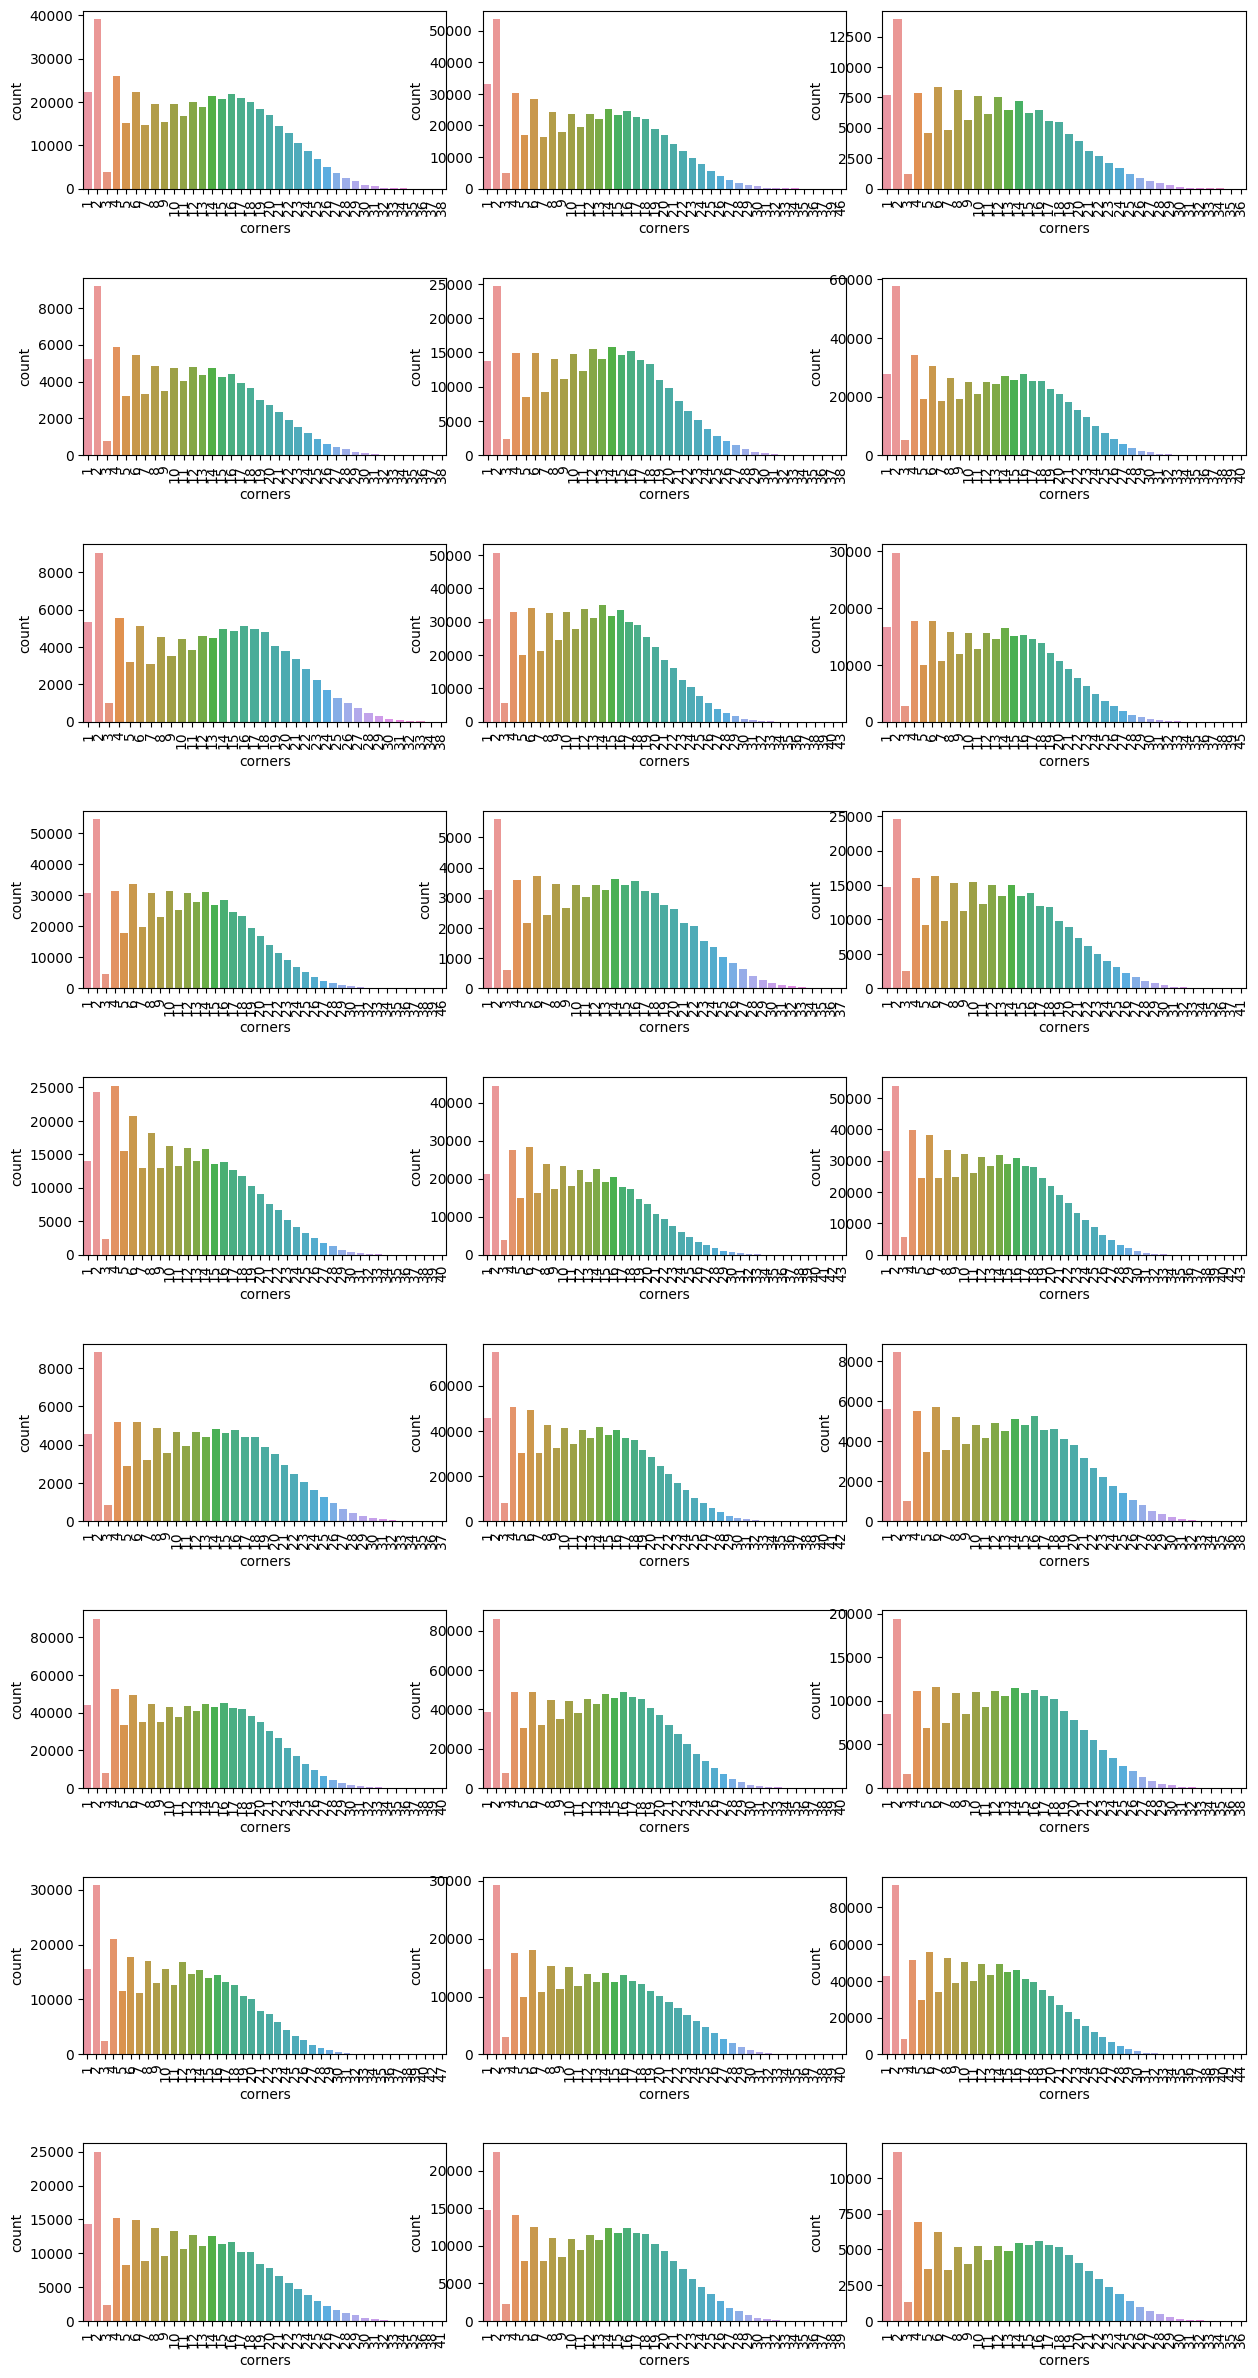

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(9, 3, figsize=(15,30))
for c,ax in zip(cat,axs.flat):
    print(c,catdict[c])
    # plt.figure() supprimé car inutile avec ax=ax
    sns.countplot(x=Dfcontour[Dfcontour['prdtypecode']==c]['corners'], ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.subplots_adjust( wspace=0.1, hspace=0.5)    
plt.show()

10 livres


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Figure size 1000x500 with 0 Axes>

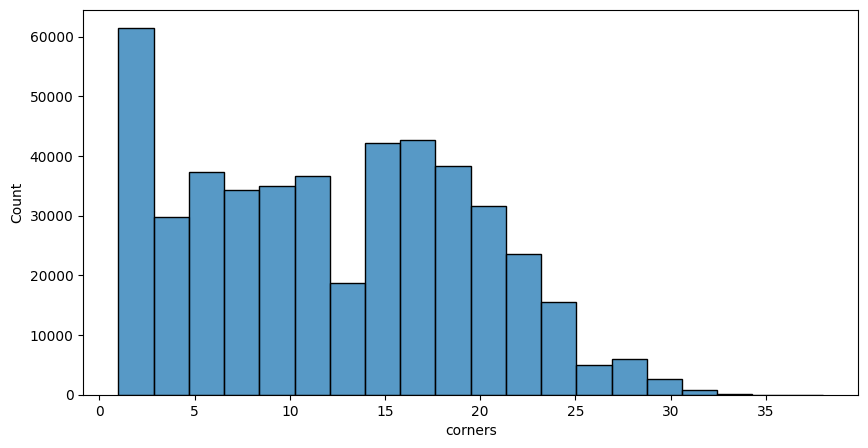

40 jeux video pour pc et consoles


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


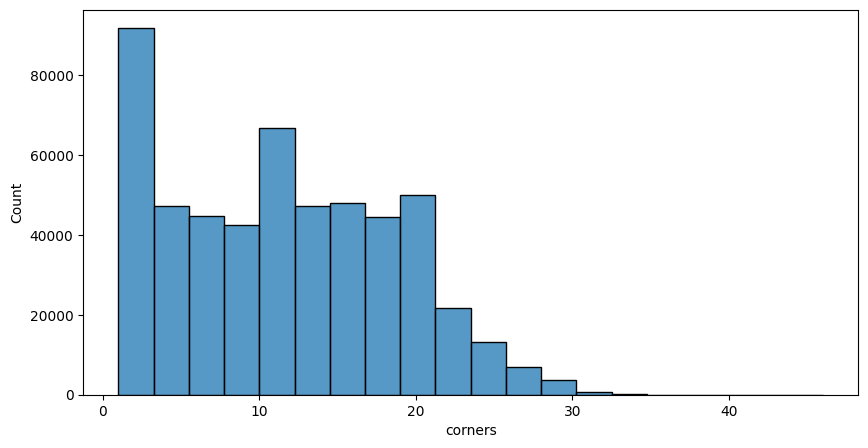

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


50  accesoires jeux video


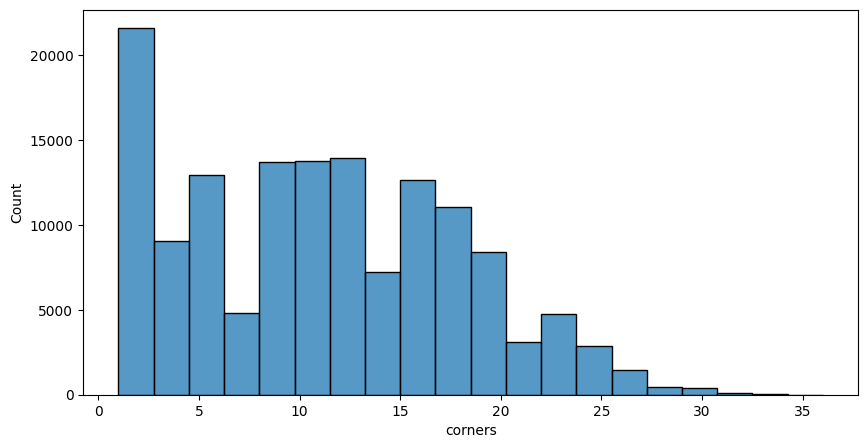

60 consoles de jeux video


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


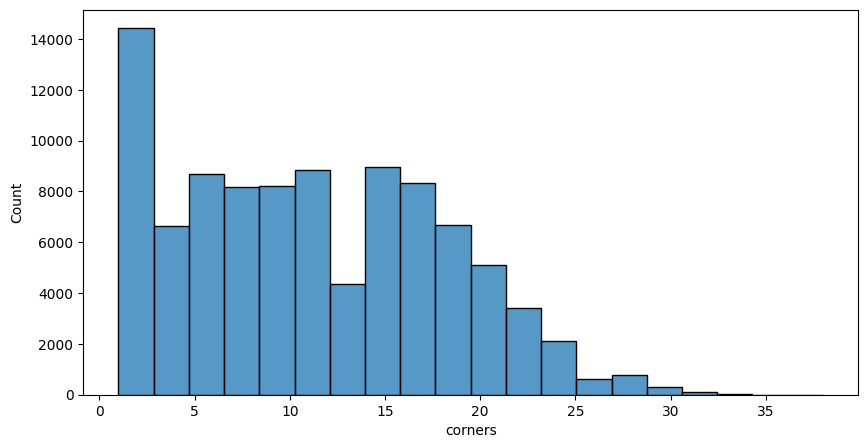

1140 produits derives “geeks” et figurines


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


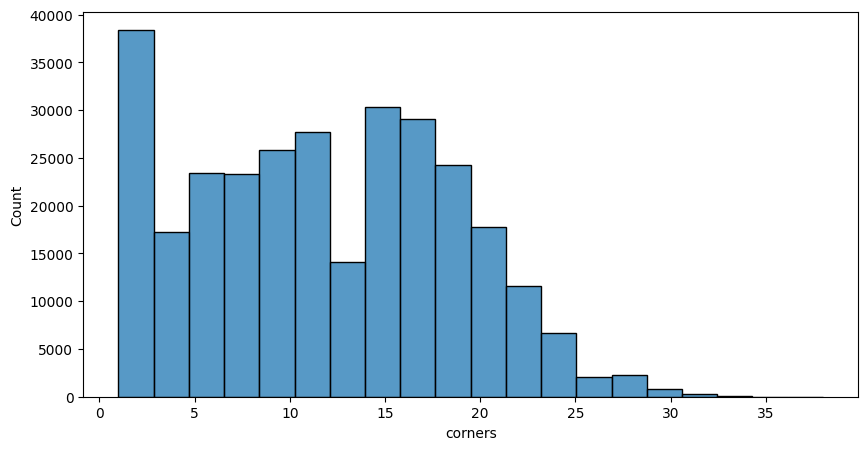

1160 cartes collectionables


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


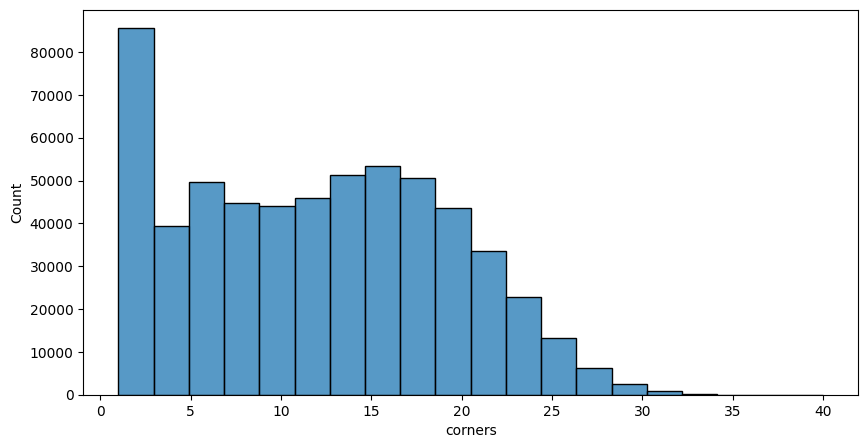

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


1180 figurines collectionables pour jeux de societe


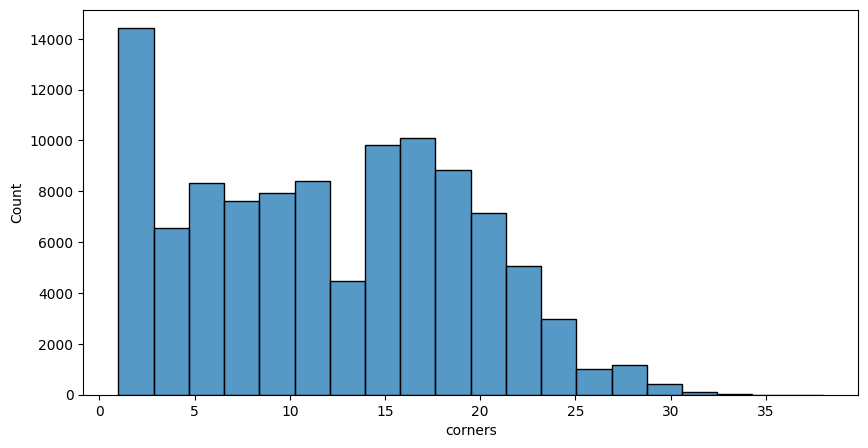

1280 jouets, peluches, poupees


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


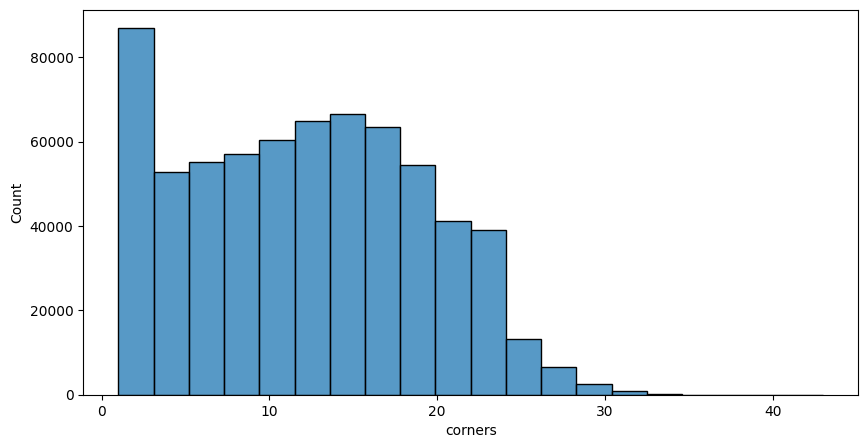

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


1281 jeux de societe/cartes


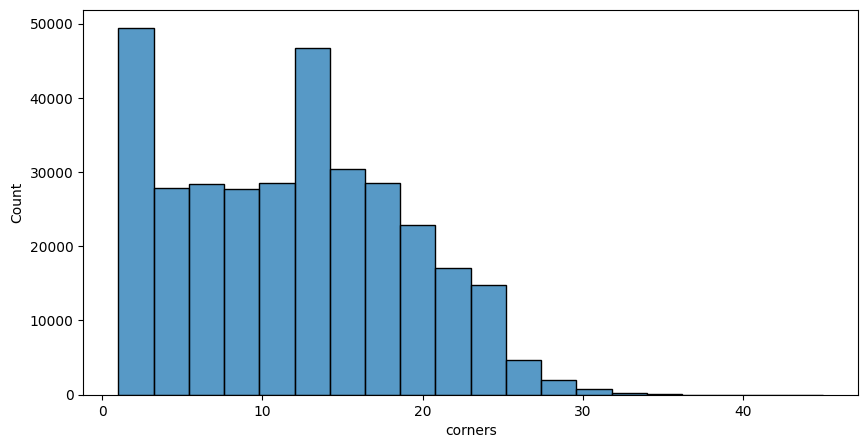

1300 Petites voitures (jouets) et maquettes


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


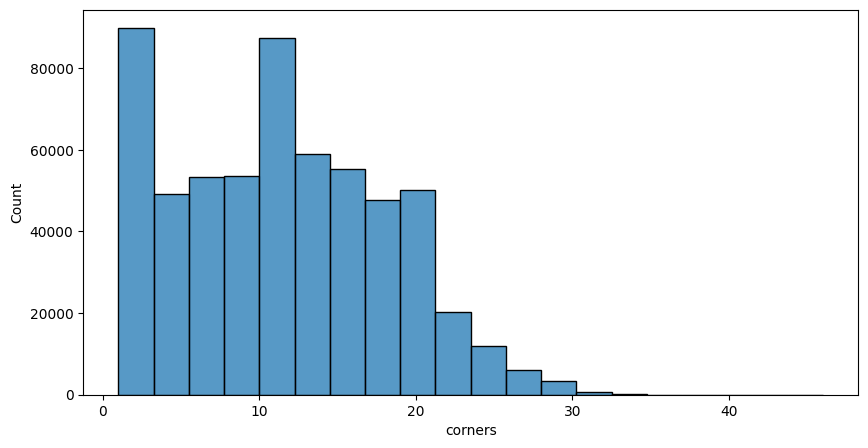

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


1301 accesoires pour petis enfants/bebes et mobilier de jeu (flechettes, billard, babyfoot)


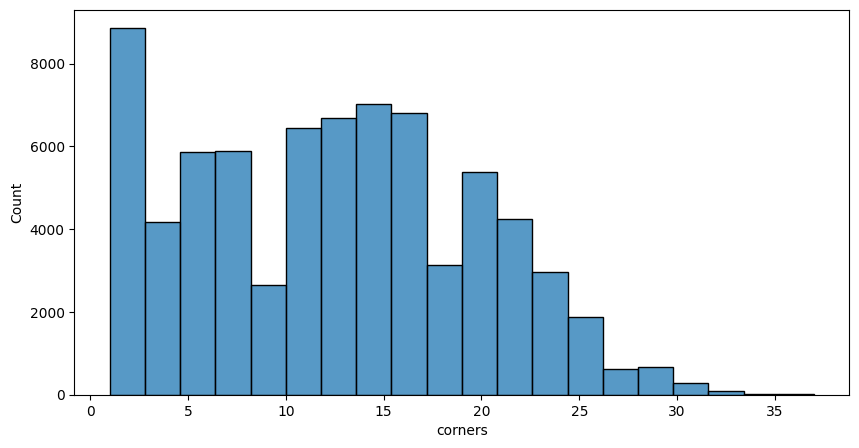

1302 jeux d'exterieur


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


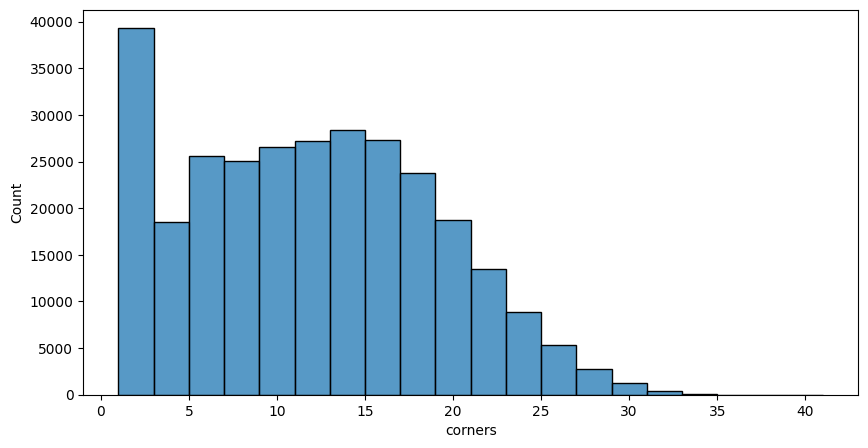

1320 sacs pour femmes et accesore petite enfance


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


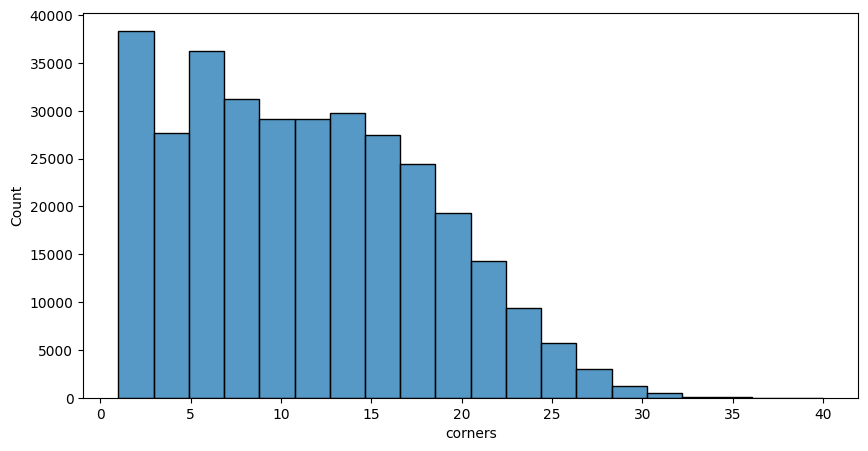

1560 Mobilier et produits decoration/rangement pour la maison


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


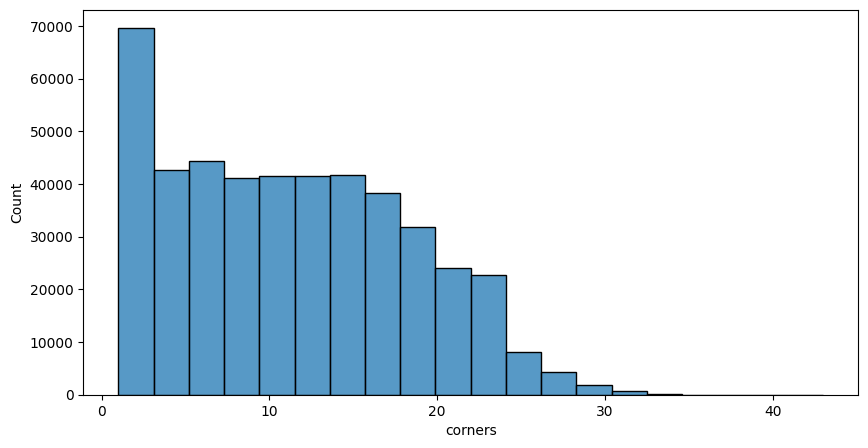

1920 linge de maison (cousins, rideaux, serviettes, nappes, draps)


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


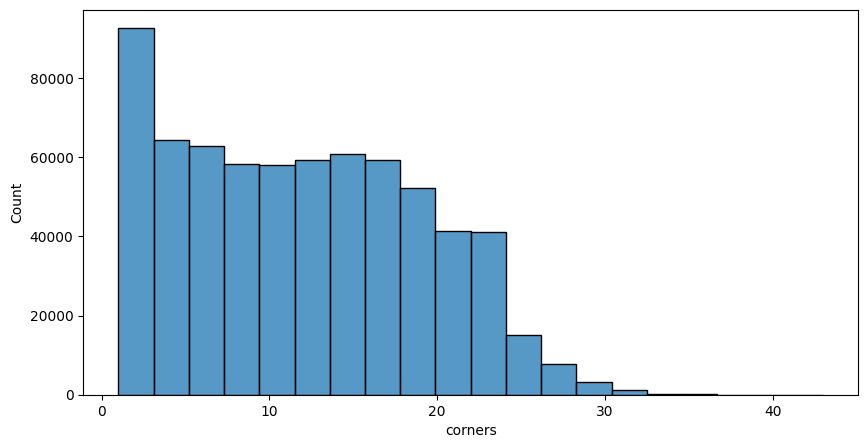

1940 nouriture (cafes,infusions,conserves, epices,etc)


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


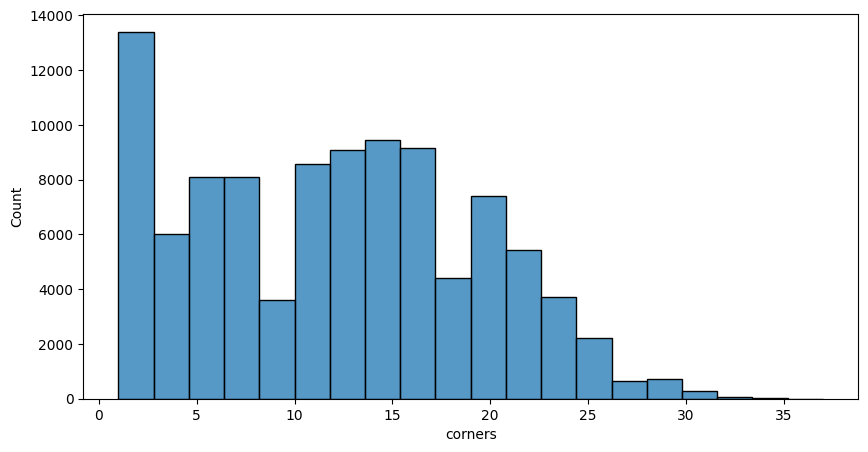

2060 lampes et accesoires decoration pour maison


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


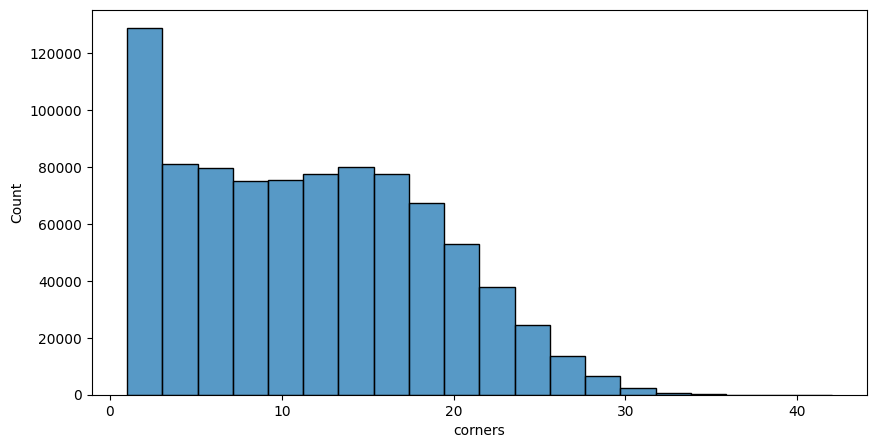

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


2220 accesoires mascots/pets


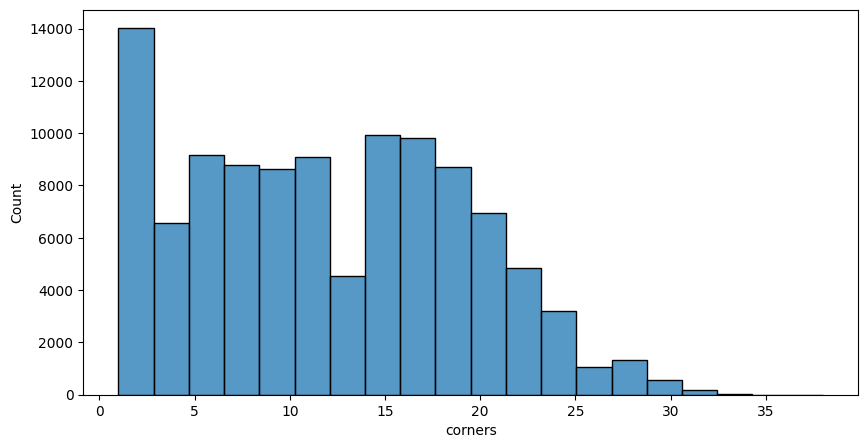

2280 magazines


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


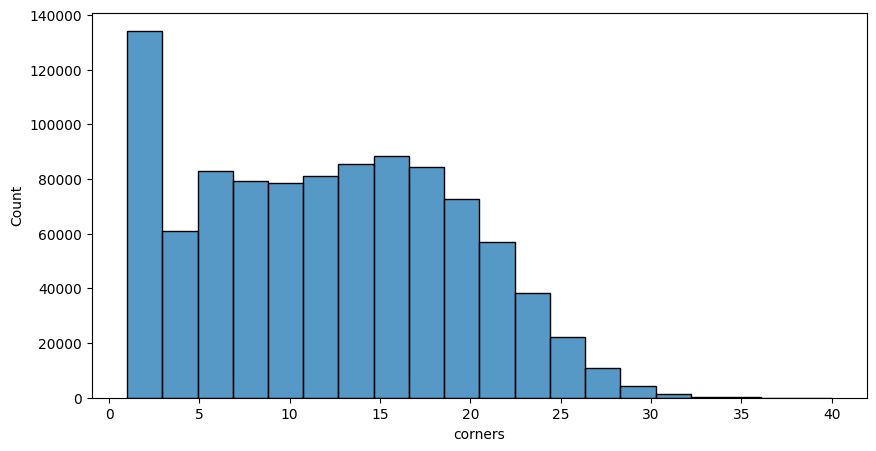

2403 livres et bds


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


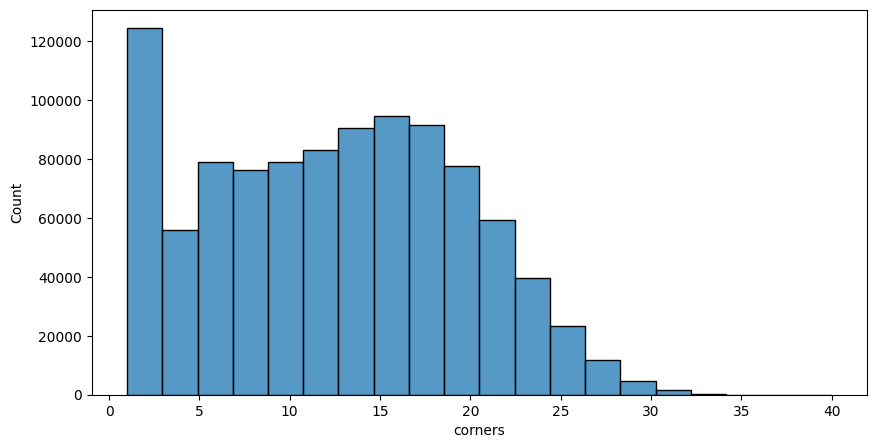

2462 consoles de jeux video et jeux videos


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


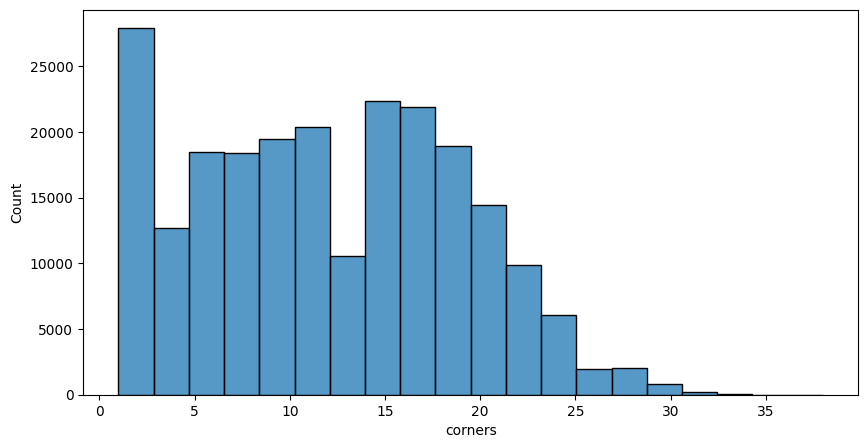

2522 produits de papeterie et rangement bureau


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


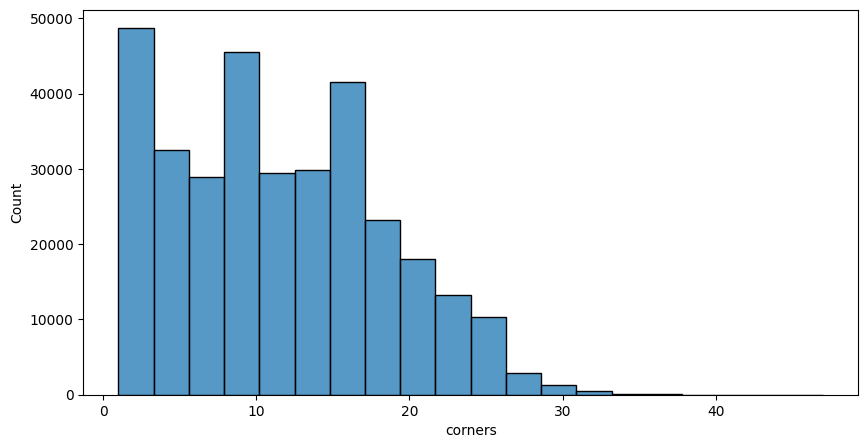

2582 mobilier d'exterieur et accesoires (parasols,pots,tentes,etc)


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


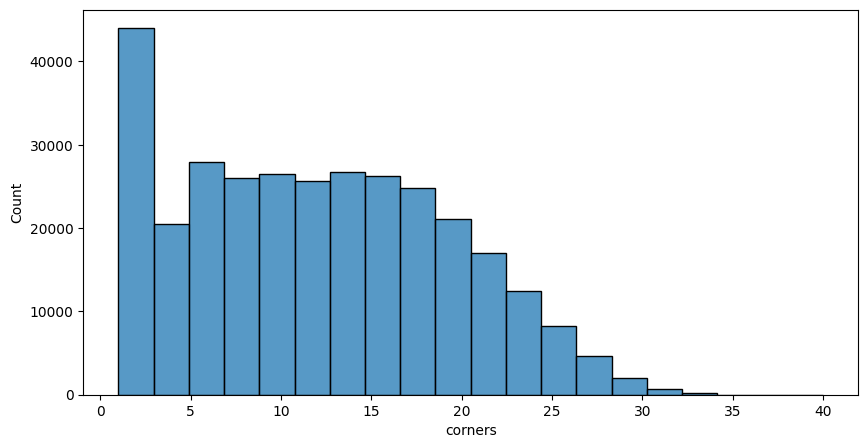

2583 accesoires de piscine


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


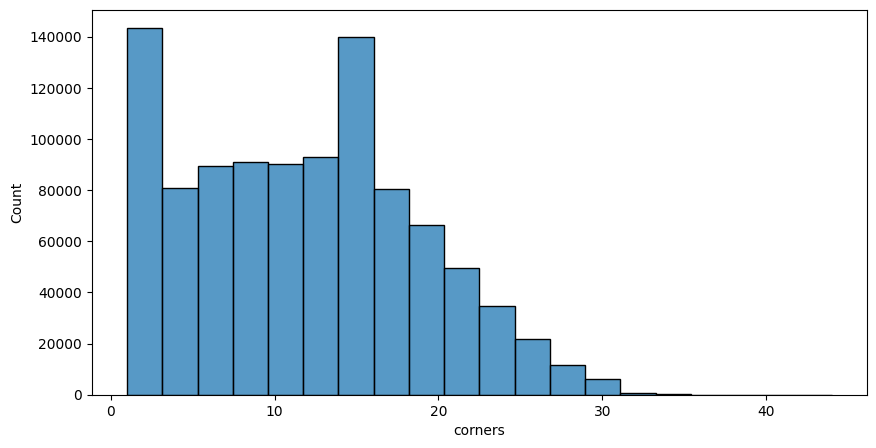

2585 outillage et accesoires pour jardinage


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


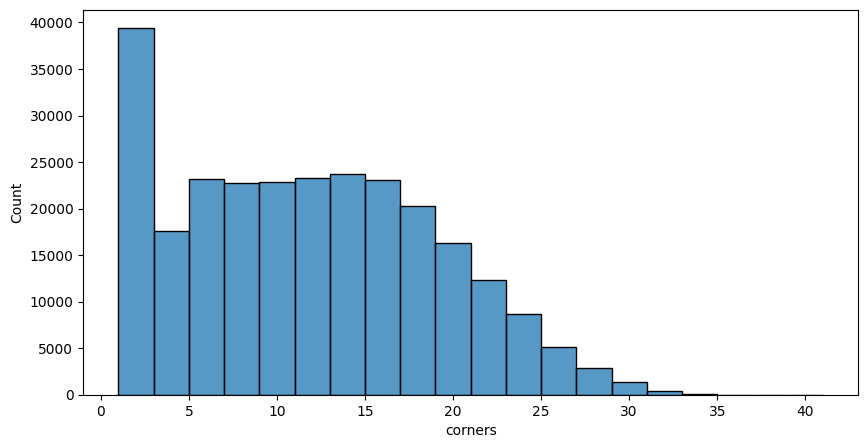

2705 bds et livres


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


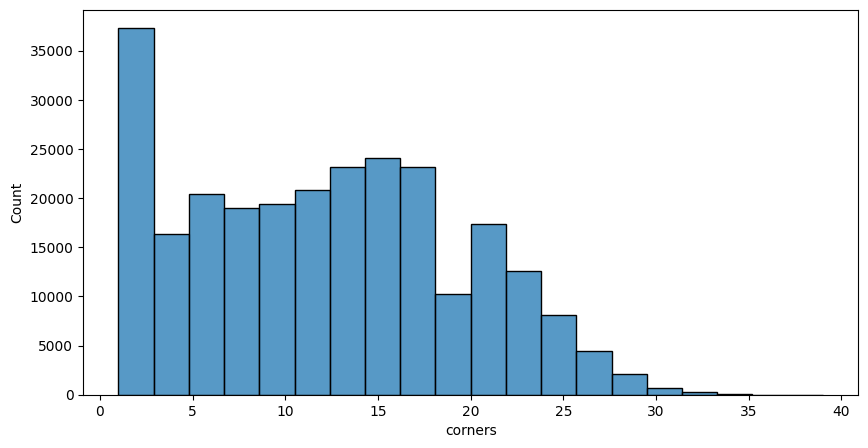

2905 Jeu En téléchargement


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


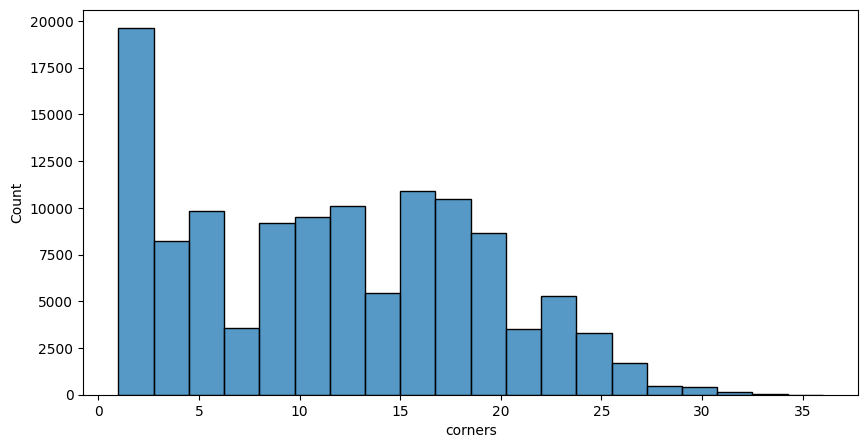

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,5))
for c in cat:
    print(c,catdict[c])
    plt.figure(figsize=(10,5))
    sns.histplot(x=Dfcontour[Dfcontour['prdtypecode']==c]['corners'],bins=20)
    plt.show()